In [1110]:
import warnings
warnings.filterwarnings('ignore')

## Análisis de negocios de Tlaxcala

In [1111]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [1112]:
data = pd.read_csv('bd_tlaxcala_reto.csv', encoding='latin-1')

In [1113]:
data.head()

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
0,19.353053,-98.166925,Salones y cl??nicas de belleza y peluquer??as,Otrosgubernamentales,9381672,ESTETICA SIN NOMBRE,0 a 5 personas,CALLE,ADOLFO LOPEZ MATEOS,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
1,19.349936,-98.169970,Centros de acondicionamiento f??sico del secto...,EsparcimientoCulturalyDeportivo,9382002,EGO SPORT GYM,0 a 5 personas,CALLE,PROLONGACION MIGUEL HIDALGO,BARRIO,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
2,19.357731,-98.172519,Consultorios de medicina general del sector pr...,SaludYAsistenciaSocial,9381669,CONSULTORIO MEDICO SIN NOMBRE,0 a 5 personas,CALLE,5 DE MAYO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
3,19.359225,-98.170541,Centros de acondicionamiento f??sico del secto...,EsparcimientoCulturalyDeportivo,9381463,CAMPO DEPORTIVO AMAXAC DE GUERRERO,0 a 5 personas,CALLE,CERRADA 5 DE MAYO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
4,19.352314,-98.167217,Lavado y lubricado de autom??viles y camiones,Otrosgubernamentales,9380994,AUTO LAVADO EL AUTO INCREIBLE,0 a 5 personas,AVENIDA,VICENTE GUERRERO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico


In [1114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82801 entries, 0 to 82800
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   lat          82801 non-null  float64
 1   long         82801 non-null  float64
 2   nombre_act   82801 non-null  object 
 3   fuente       82801 non-null  object 
 4   id           82801 non-null  int64  
 5   nom_estab    82800 non-null  object 
 6   per_ocu      82801 non-null  object 
 7   tipo_vial    82438 non-null  object 
 8   nom_vial     82801 non-null  object 
 9   tipo_asent   82587 non-null  object 
 10  cod_postal   81521 non-null  float64
 11  entidad      82801 non-null  object 
 12  municipio    82801 non-null  object 
 13  localidad    82801 non-null  object 
 14  tipoUniEco   82801 non-null  object 
 15  fecha_alta   82801 non-null  object 
 16  Tam_negocio  82801 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 10.7+ MB


In [1115]:
# Tipos de datos
data.dtypes

lat            float64
long           float64
nombre_act      object
fuente          object
id               int64
nom_estab       object
per_ocu         object
tipo_vial       object
nom_vial        object
tipo_asent      object
cod_postal     float64
entidad         object
municipio       object
localidad       object
tipoUniEco      object
fecha_alta      object
Tam_negocio     object
dtype: object

In [1116]:
# Info estadística descriptiva de las variables numéricas
data.describe()

,lat,long,id,cod_postal
count,82801.000000,82801.000000,8.280100e+04,81521.000000
mean,19.326271,-98.182462,6.104396e+06,90511.200905
std,0.116868,0.160402,2.058268e+06,446.651902
min,19.105572,-98.658093,3.329772e+06,9078.000000
25%,19.250023,-98.240206,4.172260e+06,90250.000000
50%,19.316734,-98.190979,4.209392e+06,90507.000000
75%,19.404784,-98.139888,8.085349e+06,90780.000000
max,19.700641,-97.626122,9.470746e+06,90990.000000


In [1117]:
# Valores únicos por columna
data.nunique()

lat            77718
long           77756
nombre_act       720
fuente            20
id             82801
nom_estab      56812
per_ocu            8
tipo_vial         20
nom_vial        3750
tipo_asent        39
cod_postal       332
entidad            1
municipio         75
localidad        352
tipoUniEco         2
fecha_alta        34
Tam_negocio        4
dtype: int64

In [1118]:
# Cantidad de valores nulos por columna
data.isnull().sum()   

lat               0
long              0
nombre_act        0
fuente            0
id                0
nom_estab         1
per_ocu           0
tipo_vial       363
nom_vial          0
tipo_asent      214
cod_postal     1280
entidad           0
municipio         0
localidad         0
tipoUniEco        0
fecha_alta        0
Tam_negocio       0
dtype: int64

In [1119]:
# Frecuencia por nombre de actividad 
freq = data['nombre_act'].value_counts()
freq[freq > 1000]

nombre_act
Comercio al por menor en tiendas de abarrotes, ultramarinos y miscel?°neas    11832
Elaboraci??n de tortillas de ma??z y molienda de nixtamal                      4233
Salones y cl??nicas de belleza y peluquer??as                                  2985
Comercio al por menor de art??culos de papeler??a                              2509
Comercio al por menor de ropa, excepto de beb?© y lencer??a                    2038
Restaurantes con servicio de preparaci??n de tacos y tortas                    1731
Comercio al por menor de frutas y verduras frescas                             1613
Comercio al por menor de regalos                                               1569
Servicios de preparaci??n de otros alimentos para consumo inmediato            1508
Panificaci??n tradicional                                                      1486
Comercio al por menor de carne de aves                                         1433
Comercio al por menor de carnes rojas                            

In [1120]:
# Creamos un diccionario con nombres cortos para actividades con mayor frecuencia
nombre_corto = {
    "Comercio al por menor en tiendas de abarrotes, ultramarinos y miscel?°neas": "Abarrotes",
    "Elaboraci??n de tortillas de ma??z y molienda de nixtamal": "Tortillerías",
    "Salones y cl??nicas de belleza y peluquer??as": "Belleza",
    "Comercio al por menor de art??culos de papeler??a": "Papelería",
    "Comercio al por menor de ropa, excepto de beb?© y lencer??a": "Ropa",
    "Restaurantes con servicio de preparaci??n de tacos y tortas": "Tacos y tortas",
    "Comercio al por menor de frutas y verduras frescas": "Frutas y verduras",
    "Comercio al por menor de regalos": "Regalos",
    "Servicios de preparaci??n de otros alimentos para consumo inmediato": "Otros alimentos",
    "Panificaci??n tradicional": "Panadería",
    "Comercio al por menor de carne de aves": "Carne de aves",
    "Comercio al por menor de carnes rojas": "Carnes rojas",
    "Confecci??n en serie de otra ropa exterior de materiales textiles": "Confección",
    "Reparaci??n mec?°nica en general de autom??viles y camiones": "Reparación autos",
    "Restaurantes con servicio de preparaci??n de antojitos": "Antojitos",
    "Comercio al por menor en ferreter??as y tlapaler??as": "Ferreterías",
    "Comercio al por menor de dulces y materias primas para reposter??a": "Dulcería"
}

In [1121]:
# Creamos una nueva columna con los nombres cortos
data['nombre_act'] = data['nombre_act'].map(nombre_corto)

In [1122]:
freq = data['nombre_act'].value_counts()
freq[freq > 1000]

nombre_act
Abarrotes            11832
Tortillerías          4233
Belleza               2985
Papelería             2509
Ropa                  2038
Tacos y tortas        1731
Frutas y verduras     1613
Regalos               1569
Otros alimentos       1508
Panadería             1486
Carne de aves         1433
Carnes rojas          1251
Confección            1232
Reparación autos      1165
Antojitos             1068
Ferreterías           1065
Dulcería              1038
Name: count, dtype: int64

In [1123]:
corr = data.corr(numeric_only=True)
print(corr)

                 lat      long        id  cod_postal
lat         1.000000 -0.180973  0.015443   -0.386615
long       -0.180973  1.000000 -0.020727    0.137508
id          0.015443 -0.020727  1.000000   -0.025323
cod_postal -0.386615  0.137508 -0.025323    1.000000


In [1124]:
# Mostrar registros con valores nulos en la columna 'cod_postal'
cp_nas = data[data['cod_postal'].isnull()]

In [1125]:
# Contar frecuencia de municipios en CP faltantes
cp_nas.groupby('municipio').size().sort_values(ascending=False)

municipio
Zacatelco                           154
San Pablo del Monte                 136
Calpulalpan                         111
Tlaxcala                            106
Huamantla                           102
Terrenate                            72
Santa Isabel Xiloxoxtla              65
Amaxac de Guerrero                   56
Tocatl?°n                            50
Apizaco                              48
Cuapiaxtla                           45
Papalotla de Xicoht?©ncatl           43
Ixtenco                              36
Chiautempan                          35
Totolac                              30
Ixtacuixtla de Mariano Matamoros     28
Atltzayanca                          25
Sanct??rum de L?°zaro C?°rdenas      25
Tzompantepec                         17
Yauhquemehcan                        10
Benito Ju?°rez                       10
Xaloztoc                              9
Tetla de la Solidaridad               9
Tenancingo                            7
Xicohtzinco                   

In [1126]:
cp_nas.head()

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
0,19.353053,-98.166925,Belleza,Otrosgubernamentales,9381672,ESTETICA SIN NOMBRE,0 a 5 personas,CALLE,ADOLFO LOPEZ MATEOS,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
1,19.349936,-98.169970,NaN,EsparcimientoCulturalyDeportivo,9382002,EGO SPORT GYM,0 a 5 personas,CALLE,PROLONGACION MIGUEL HIDALGO,BARRIO,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
2,19.357731,-98.172519,NaN,SaludYAsistenciaSocial,9381669,CONSULTORIO MEDICO SIN NOMBRE,0 a 5 personas,CALLE,5 DE MAYO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
3,19.359225,-98.170541,NaN,EsparcimientoCulturalyDeportivo,9381463,CAMPO DEPORTIVO AMAXAC DE GUERRERO,0 a 5 personas,CALLE,CERRADA 5 DE MAYO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
4,19.352314,-98.167217,NaN,Otrosgubernamentales,9380994,AUTO LAVADO EL AUTO INCREIBLE,0 a 5 personas,AVENIDA,VICENTE GUERRERO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico


In [1127]:
# Vemos si se da el caso en donde el registro de CP faltante para un municipio y localidad está en algún otro registro
data[data['municipio']=='Amaxac de Guerrero']

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
0,19.353053,-98.166925,Belleza,Otrosgubernamentales,9381672,ESTETICA SIN NOMBRE,0 a 5 personas,CALLE,ADOLFO LOPEZ MATEOS,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
1,19.349936,-98.169970,NaN,EsparcimientoCulturalyDeportivo,9382002,EGO SPORT GYM,0 a 5 personas,CALLE,PROLONGACION MIGUEL HIDALGO,BARRIO,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
2,19.357731,-98.172519,NaN,SaludYAsistenciaSocial,9381669,CONSULTORIO MEDICO SIN NOMBRE,0 a 5 personas,CALLE,5 DE MAYO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
3,19.359225,-98.170541,NaN,EsparcimientoCulturalyDeportivo,9381463,CAMPO DEPORTIVO AMAXAC DE GUERRERO,0 a 5 personas,CALLE,CERRADA 5 DE MAYO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
4,19.352314,-98.167217,NaN,Otrosgubernamentales,9380994,AUTO LAVADO EL AUTO INCREIBLE,0 a 5 personas,AVENIDA,VICENTE GUERRERO,SECCION,NaN,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2021-11,Chico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35374,19.347103,-98.169761,NaN,Otrosgubernamentales,4167518,CERRAJERIA MOY,0 a 5 personas,CALLE,16 DE SEPTIEMBRE,BARRIO,90620.0,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2010-07,Chico
35375,19.344792,-98.173397,Reparación autos,Otrosgubernamentales,7512069,TALLER MECANICO SIN NOMBRE,0 a 5 personas,PRIVADA,VENUSTIANO CARRANZA,BARRIO,90620.0,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2019-11,Chico
35376,19.344077,-98.168682,NaN,Otrosgubernamentales,7512064,ASOCIACION DE MINUSVALIDOS DEL ESTADO DE TLAXCALA,0 a 5 personas,CALLE,FRANCISCO I. MADERO,BARRIO,90620.0,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2019-11,Chico
35377,19.346458,-98.171907,Belleza,Otrosgubernamentales,4194917,ESTETICA,0 a 5 personas,CALLE,FRANCISCO I. MADERO,BARRIO,90620.0,Tlaxcala,Amaxac de Guerrero,Amaxac de Guerrero ...,Fijo,2014-12,Chico


Arreglamos esto, buscando que si existe algún otro registro con el mismo municipio y localidad, se coloque el CP del registro en donde no aparece como NA.

In [1128]:
# Crear tabla auxiliar SOLO con registros que sí tienen CP
cp_lookup = (
    data[data['cod_postal'].notna()]
    [['municipio', 'localidad', 'cod_postal']]
    .drop_duplicates(subset=['municipio', 'localidad'])
)

# Hacer merge
data = data.merge(
    cp_lookup,
    on=['municipio', 'localidad'],
    how='left',
    suffixes=('', '_nuevo')
)

# Rellenar solo los NA
data['cod_postal'] = data['cod_postal'].fillna(data['cod_postal_nuevo'])

# Eliminar columna auxiliar
data.drop(columns=['cod_postal_nuevo'], inplace=True)

In [1129]:
data['cod_postal'].isnull().sum()

2

In [1130]:
cp_nas_clean = data[data['cod_postal'].isnull()]
cp_nas_clean

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
687,19.150626,-98.126131,NaN,ComercioAlPorMenor,9302076,MARIMONI OPERADORA DE SERVICIOS,0 a 5 personas,CALLE,ALHONDIGA DE GRANADITAS,COLONIA,NaN,Tlaxcala,San Pablo del Monte,Cacamila San Antonio ...,Fijo,2020-11,Chico
806,19.250860,-98.167178,NaN,Construccion,9313412,SARYCSA & ASOCIADOS,11 a 30 personas,AVENIDA,JUAREZ,PUEBLO,NaN,Tlaxcala,Teolocholco,Acxotla del Monte ...,Fijo,2020-11,Chico


In [1131]:
data.loc[(data['id'] == 9302076), 'cod_postal'] = 90901
data.loc[(data['id'] == 9313412), 'cod_postal'] = 90801

In [1132]:
# Verificar que ya no hay NAs para CP
data.isnull().sum()

lat                0
long               0
nombre_act     43045
fuente             0
id                 0
nom_estab          1
per_ocu            0
tipo_vial        363
nom_vial           0
tipo_asent       214
cod_postal         0
entidad            0
municipio          0
localidad          0
tipoUniEco         0
fecha_alta         0
Tam_negocio        0
dtype: int64

In [1133]:
# Ver frecuencia de cada código postal
data['cod_postal'].value_counts()

cod_postal
90300.0    4203
90800.0    3042
90500.0    2935
90740.0    2794
90000.0    2268
           ... 
90127.0       1
90551.0       1
90557.0       1
90558.0       1
9078.0        1
Name: count, Length: 332, dtype: int64

In [1134]:
cod_raros = data[data['cod_postal'] < 90000]['cod_postal'].value_counts()
cod_raros

cod_postal
72160.0    3
72540.0    1
72425.0    1
72260.0    1
72170.0    1
72140.0    1
66260.0    1
9078.0     1
Name: count, dtype: int64

In [1135]:
# Mostrar registros con códigos postales raros
data[data['cod_postal'].isin(cod_raros.index)]

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
82791,19.232343,-98.193275,NaN,ServiciosFinancieros,6845010,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,72540.0,Tlaxcala,Teolocholco,Teolocholco ...,Fijo,2018-03,Chico
82792,19.535966,-98.192412,NaN,ServiciosFinancieros,6838110,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,72425.0,Tlaxcala,Atlangatepec,Rancho Xalnene ...,Fijo,2018-03,Chico
82793,19.419470,-98.157780,NaN,ServiciosFinancieros,6849790,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,J. CARRANZA,COLONIA,72260.0,Tlaxcala,Yauhquemehcan,Santa ?örsula Zimatepec ...,Fijo,2018-03,Chico
82794,19.511029,-98.246693,NaN,ServiciosFinancieros,6849791,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,72170.0,Tlaxcala,San Lucas Tecopilco,Las Ca?±adas ...,Fijo,2018-03,Chico
82795,19.531715,-98.221578,NaN,ServiciosFinancieros,6838112,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,72160.0,Tlaxcala,Atlangatepec,Colonia Loma Bonita ...,Fijo,2018-03,Chico
82796,19.551195,-98.230190,NaN,ServiciosFinancieros,6838111,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,72160.0,Tlaxcala,Atlangatepec,Colonia Benito Ju?°rez (Tezoyo) ...,Fijo,2018-03,Chico
82797,19.600160,-98.226499,NaN,ServiciosFinancieros,6838901,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,72160.0,Tlaxcala,Tlaxco,Tliltepec ...,Fijo,2018-03,Chico
82798,19.597650,-98.219987,NaN,ServiciosFinancieros,6888483,BANAMEX,0 a 5 personas,BOULEVARD,HERMANOS SERDAN,PARQUE INDUSTRIAL,72140.0,Tlaxcala,Tlaxco,San Antonio Huexotitla ...,Fijo,2019-04,Chico
82799,19.489306,-98.059585,NaN,IndustriaManufacturera,9425588,STONE CER,251 y m?°s personas,AVENIDA,EMILIO SANCHEZ PIE,COLONIA,66260.0,Tlaxcala,Tetla de la Solidaridad,Jos?© Mar??a Morelos y Pav??n ...,Fijo,2023-11,Grande
82800,19.174554,-98.231077,NaN,IndustriaManufacturera,9390322,MONTERAL TEJIDOS TEXTILES Y ALGO MAS,51 a 100 personas,CALLE,AN LOS ANGELES,BARRIO,9078.0,Tlaxcala,Xicohtzinco,Xicohtzinco ...,Fijo,2022-11,Mediano


In [1136]:
# Reemplazamos codigos postales incorrectos (no correspondientes al estado de Tlaxcala) por los adecuados
# Nos basamos en la base de datos de https://www.correosdemexico.gob.mx/sslservicios/consultacp/CodigoPostal_Exportar.aspx

data.loc[(data['municipio'] == 'Teolocholco'), 'cod_postal'] = 90801
data.loc[(data['municipio'] == 'Atlangatepec'), 'cod_postal'] = 90301
data.loc[(data['municipio'] == 'Yauhquemehcan'), 'cod_postal'] = 90451
data.loc[(data['municipio'] == 'San Lucas Tecopilco'), 'cod_postal'] = 90301
data.loc[(data['municipio'] == 'Tlaxco'), 'cod_postal'] = 90252
data.loc[(data['municipio'] == 'Tetla de la Solidaridad'), 'cod_postal'] = 90301
data.loc[(data['municipio'] == 'Xicohtzinco'), 'cod_postal'] = 90781

In [1137]:
cod_raros = data[data['cod_postal'] < 90000]['cod_postal'].value_counts()
cod_raros

Series([], Name: count, dtype: int64)

In [1138]:
consistencia = (
    data.groupby('cod_postal')
    .agg({
        'municipio': 'nunique',
        'localidad': 'nunique'
    })
    .reset_index()
)

consistencia

,cod_postal,municipio,localidad
0,90000.0,6,13
1,90001.0,1,3
2,90006.0,1,2
3,90008.0,1,1
4,90010.0,1,2
...,...,...,...
296,90963.0,1,1
297,90970.0,5,6
298,90980.0,1,2
299,90982.0,1,1


In [1139]:
consistencia[consistencia['municipio'] > 1]

,cod_postal,municipio,localidad
0,90000.0,6,13
5,90013.0,2,2
8,90030.0,3,4
9,90040.0,2,4
12,90062.0,2,5
...,...,...,...
281,90870.0,4,3
285,90880.0,4,6
288,90900.0,2,2
293,90940.0,3,3


In [1140]:
# Ver en que municipio se encuentra cada código postal faltante
data[data['cod_postal'].isnull()]['municipio'].value_counts()

Series([], Name: count, dtype: int64)

In [1141]:
data['cod_postal'] = data['cod_postal'].astype(int)

In [1142]:
# Mostrar filas donde 'nom_estab' es null
null_rows = data[data['nom_estab'].isnull()]
null_rows

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
8592,19.226139,-98.205787,NaN,AlojamientoTemporalyComida,4180658,NaN,0 a 5 personas,CALLE,REFORMA,PUEBLO,90860,Tlaxcala,Acuamanala de Miguel Hidalgo,Acuamanala ...,Fijo,2014-12,Chico


In [1143]:
nombres = null_rows['nombre_act'].unique()

mismos = data[data['nombre_act'].isin(nombres)]

In [1144]:
filtro = mismos[mismos['nom_vial'] =='REFORMA']
filtro = filtro[filtro['tipo_asent']=='PUEBLO']
filtro

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
8592,19.226139,-98.205787,NaN,AlojamientoTemporalyComida,4180658,NaN,0 a 5 personas,CALLE,REFORMA,PUEBLO,90860,Tlaxcala,Acuamanala de Miguel Hidalgo,Acuamanala ...,Fijo,2014-12,Chico
8753,19.228447,-98.211521,NaN,Otrosgubernamentales,7141754,ELECTROEMB Y SERVICIOS ESPECIALES PC,0 a 5 personas,AVENIDA,REFORMA,PUEBLO,90801,Tlaxcala,Teolocholco,El Carmen Aztama ...,Fijo,2019-11,Chico
8784,19.228627,-98.211999,NaN,ComercioAlPorMayor,4142390,AGROPECUAR?çA ZARAGOZA,6 a 10 personas,AVENIDA,REFORMA,PUEBLO,90801,Tlaxcala,Teolocholco,El Carmen Aztama ...,Fijo,2010-07,Chico
8827,19.228330,-98.211423,NaN,IndustriaManufacturera,7141752,SEPIREM,6 a 10 personas,AVENIDA,REFORMA,PUEBLO,90801,Tlaxcala,Teolocholco,El Carmen Aztama ...,Fijo,2019-11,Chico
8828,19.229868,-98.215271,NaN,AlojamientoTemporalyComida,7141751,DO?ëA BLANCA,0 a 5 personas,AVENIDA,REFORMA,PUEBLO,90801,Tlaxcala,Teolocholco,El Carmen Aztama ...,Fijo,2019-11,Chico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70421,19.323882,-98.238218,NaN,ComercioAlPorMenor,9326343,NUEVA ESPERANZA TLAXCALA,0 a 5 personas,CALLE,REFORMA,PUEBLO,90160,Tlaxcala,Totolac,Acxotla del R??o ...,Fijo,2020-11,Chico
76103,19.280186,-98.256819,NaN,Otrosgubernamentales,4162400,IGLESIA DE SAN DIEGO METEPEC,6 a 10 personas,AVENIDA,REFORMA,PUEBLO,90110,Tlaxcala,Tlaxcala,San Diego Metepec ...,Fijo,2010-07,Chico
76167,19.279819,-98.256924,NaN,ActividadesLegislativas,4162401,PRESIDENCIA AUXILIAR DE COMUNIDAD DE SAN DIEGO...,11 a 30 personas,AVENIDA,REFORMA,PUEBLO,90110,Tlaxcala,Tlaxcala,San Diego Metepec ...,Fijo,2010-07,Chico
76187,19.273113,-98.259597,NaN,Otrosgubernamentales,8058931,PANTEON DE LA COMUNIDAD DE SAN DIEGO METEPEC,0 a 5 personas,AVENIDA,REFORMA,PUEBLO,90110,Tlaxcala,Tlaxcala,San Diego Metepec ...,Fijo,2019-11,Chico


### Visualización de variables categórcias

In [1145]:
# Variables categóricas con pocas categorías únicas para visualización
cat_vars = ['fuente', 'per_ocu', 'tipo_vial', 'tipo_asent', 'municipio','tipoUniEco', 'fecha_alta','Tam_negocio']

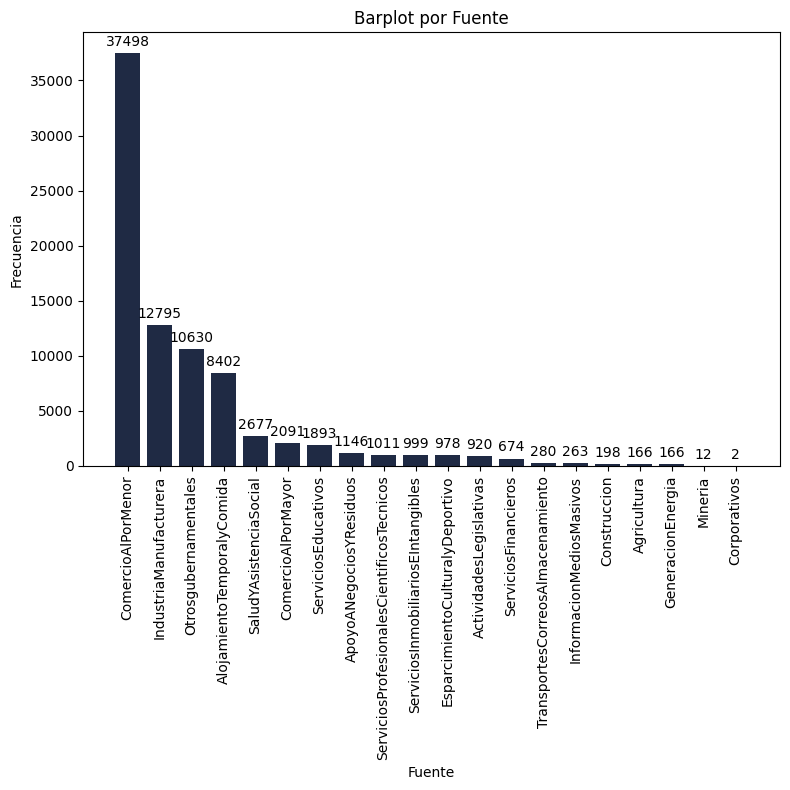

In [1146]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['fuente'].value_counts()  
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Fuente') 
ax.set_xlabel('Fuente')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

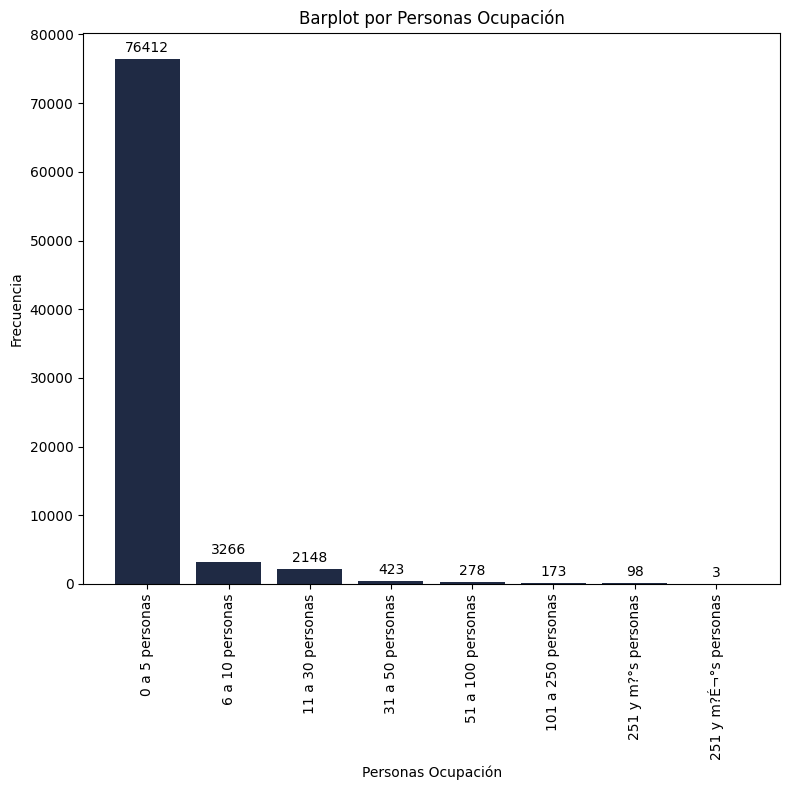

In [1147]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['per_ocu'].value_counts() 
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44') 

ax.set_title('Barplot por Personas Ocupación') 
ax.set_xlabel('Personas Ocupación')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

Al analizar la variable per_ocu se identificó que la categoría correspondiente a “251 personas y más” aparece duplicada debido a un problema de codificación de caracteres, generando dos etiquetas distintas que en realidad representan el mismo rango de ocupación. Por ello, se decidió unificar ambas etiquetas en una sola categoría estandarizada.

In [1148]:
data['per_ocu'].unique()

array(['0 a 5 personas', '51 a 100 personas', '101 a 250 personas',
       '6 a 10 personas', '11 a 30 personas', '251 y m?°s personas',
       '31 a 50 personas', '251 y m?É¬°s personas'], dtype=object)

In [1149]:
# Unificar todas las variantes de "251 y más personas"
data['per_ocu'] = data['per_ocu'].str.replace(
    r'251.*personas',
    '251 y más personas',
    regex=True
)

# Definir orden correcto
orden = [
    '0 a 5 personas',
    '6 a 10 personas',
    '11 a 30 personas',
    '31 a 50 personas',
    '51 a 100 personas',
    '101 a 250 personas',
    '251 y más personas'
]

data['per_ocu'] = pd.Categorical(
    data['per_ocu'],
    categories=orden,
    ordered=True
)

print(data['per_ocu'].value_counts().sort_index())

per_ocu
0 a 5 personas        76412
6 a 10 personas        3266
11 a 30 personas       2148
31 a 50 personas        423
51 a 100 personas       278
101 a 250 personas      173
251 y más personas      101
Name: count, dtype: int64


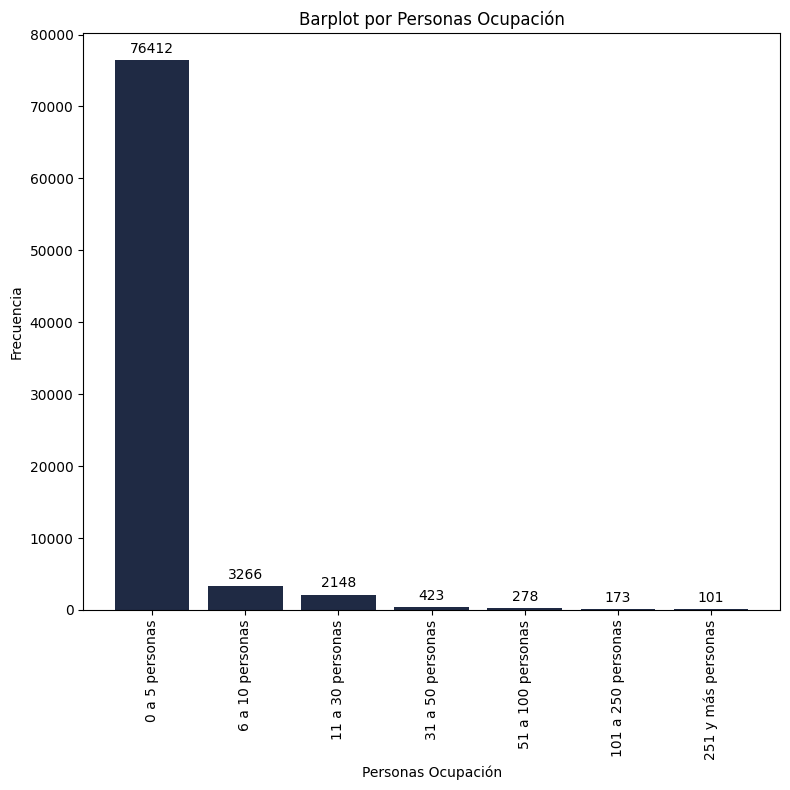

In [1150]:
# Versión corregida del gráfico de barras para 'per_ocu' con categorías unificadas y ordenadas
fig, ax = plt.subplots(figsize=(8,8))

freq = data['per_ocu'].value_counts() 
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44') 

ax.set_title('Barplot por Personas Ocupación') 
ax.set_xlabel('Personas Ocupación')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

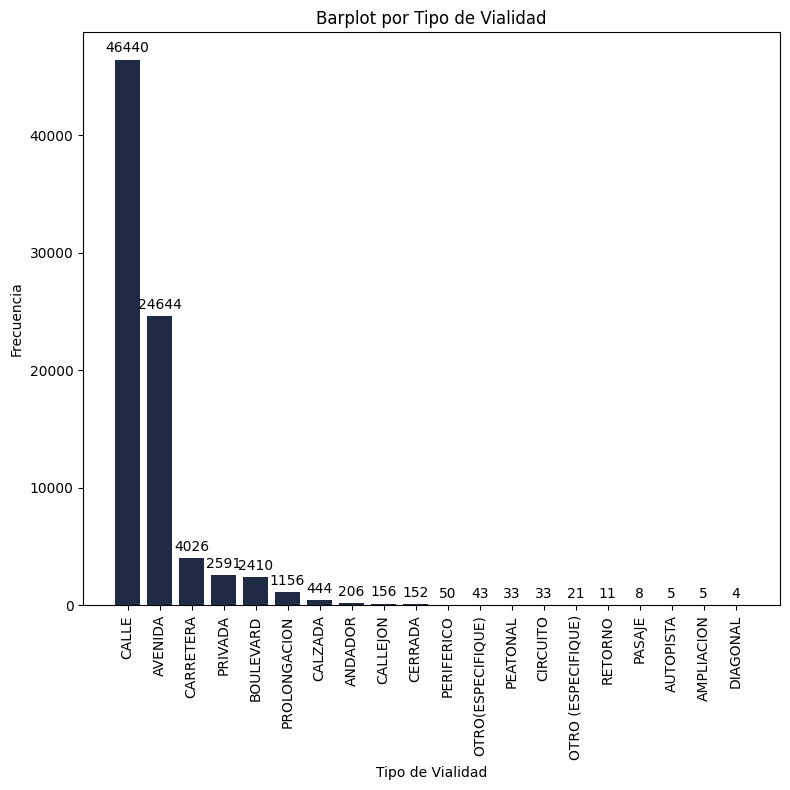

In [1151]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['tipo_vial'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Tipo de Vialidad') 
ax.set_xlabel('Tipo de Vialidad')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

Al revisar la variable tipo de vialidad, se detectó que la categoría “OTRO (ESPECIFIQUE)” aparece duplicada debido a una inconsistencia en el registro, una versión contiene un espacio adicional y la otra no. Esta diferencia no representa una categoría distinta en términos conceptuales, sino un error de captura o formato. Por ello, se procedió a unificar ambas entradas bajo una sola categoría estandarizada: “OTRO (ESPECIFIQUE)”, eliminando diferencias de formato irrelevantes.

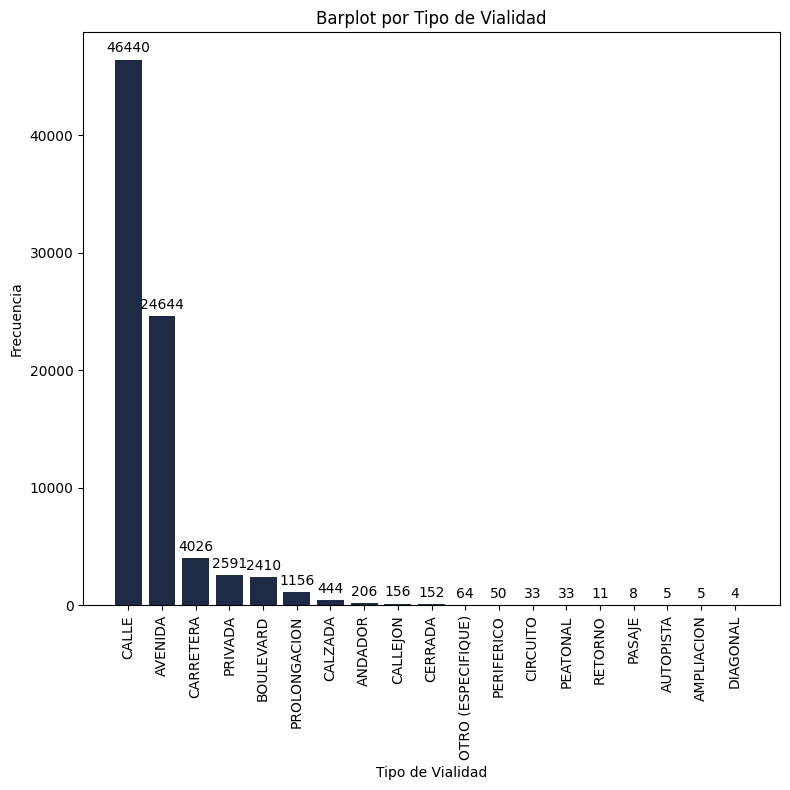

In [1152]:
data['tipo_vial'] = data['tipo_vial'].replace('OTRO(ESPECIFIQUE)', 'OTRO (ESPECIFIQUE)')
fig, ax = plt.subplots(figsize=(8,8))

freq = data['tipo_vial'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Tipo de Vialidad') 
ax.set_xlabel('Tipo de Vialidad')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

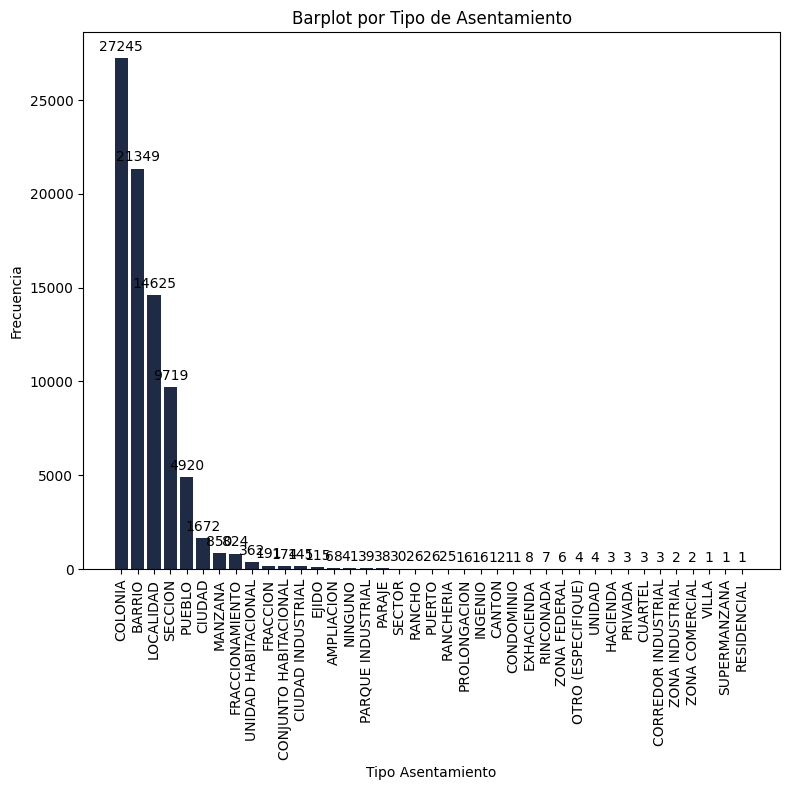

In [1153]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['tipo_asent'].value_counts() 
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44') 

ax.set_title('Barplot por Tipo de Asentamiento') 
ax.set_xlabel('Tipo Asentamiento')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

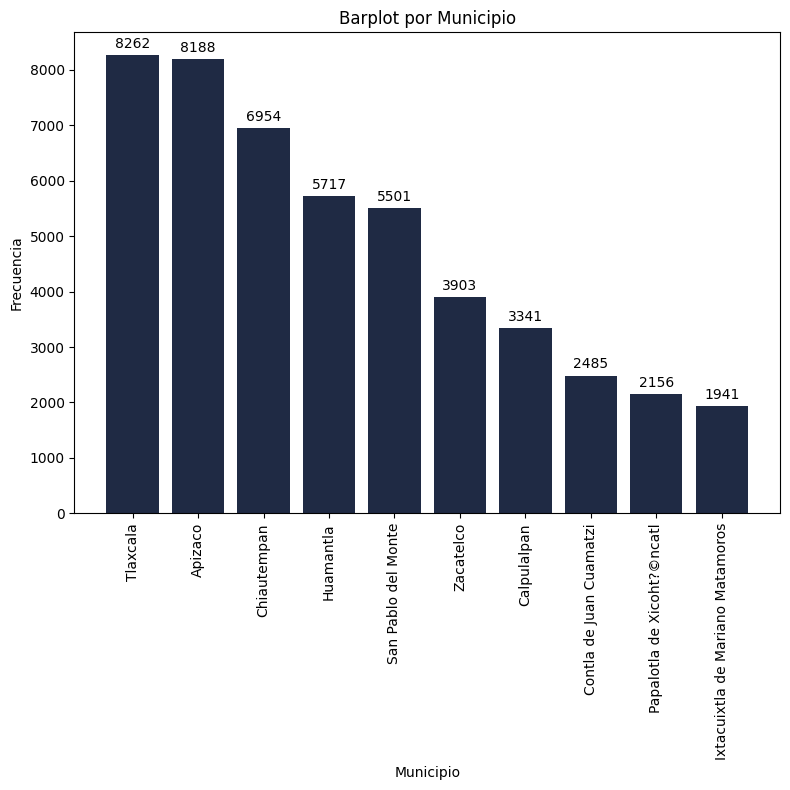

In [1154]:
fig, ax = plt.subplots(figsize=(8,8))

# Top 10, ya que hay muchos municipios (75), para evitar un gráfico saturado
freq = data['municipio'].value_counts() .head(10)
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44') 

ax.set_title('Barplot por Municipio') 
ax.set_xlabel('Municipio')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

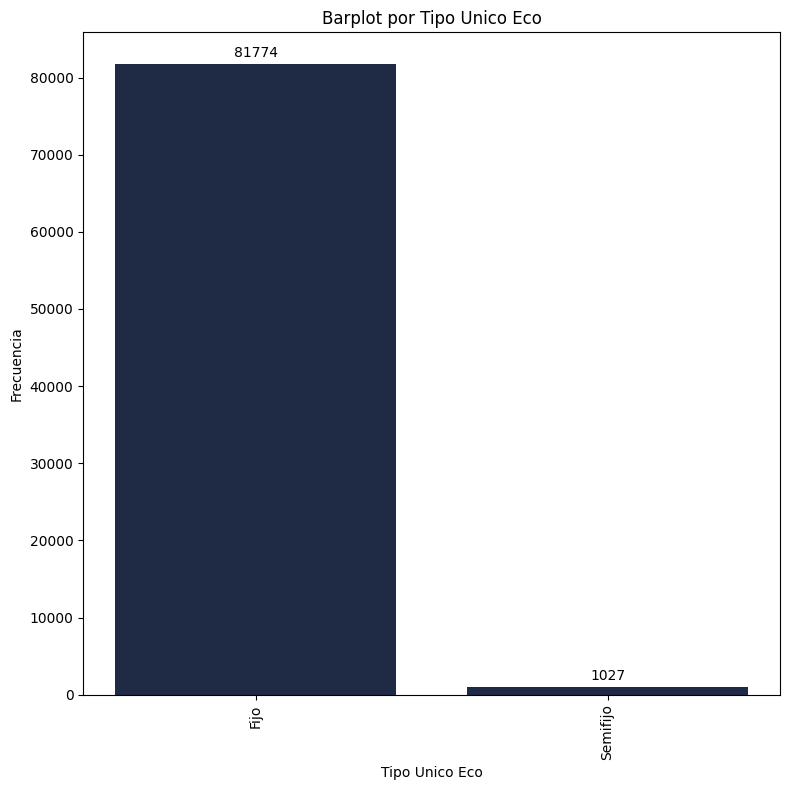

In [1155]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['tipoUniEco'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Tipo Unico Eco') 
ax.set_xlabel('Tipo Unico Eco')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

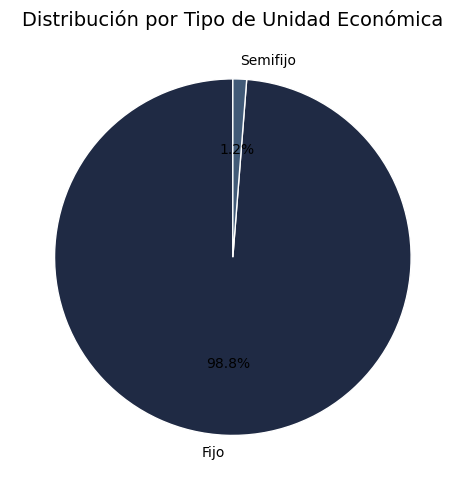

In [1156]:
# Contar frecuencias
freq = data['tipoUniEco'].value_counts()

# Paleta de colores
colores = ['#1F2A44', '#415A77', '#6C8EBF', '#8D99AE']

# Crear gráfico de pastel
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(
    freq, 
    labels=freq.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colores[:len(freq)], 
    wedgeprops={'edgecolor':'white'} 
)
ax.set_title('Distribución por Tipo de Unidad Económica', fontsize=14)

plt.tight_layout()
plt.show()

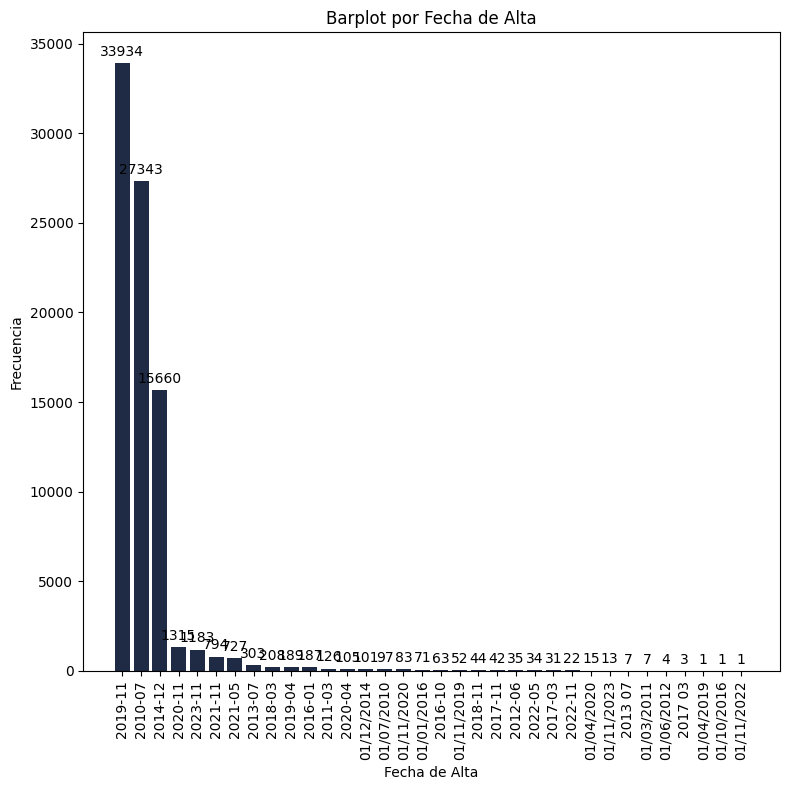

In [1157]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['fecha_alta'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Fecha de Alta') 
ax.set_xlabel('Fecha de Alta')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

In [1158]:
data['fecha_alta'].unique()

array(['2021-11', '2021-05', '2014-12', '2010-07', '2020-11', '2016-01',
       '2016-10', '01/11/2020', '01/07/2010', '2017 03', '2011-03',
       '01/12/2014', '2012-06', '2019-11', '01/03/2011', '2013-07',
       '2023-11', '01/01/2016', '2018-03', '2017-11', '2020-04',
       '2019-04', '01/11/2019', '01/04/2020', '2022-05', '2017-03',
       '2018-11', '2022-11', '2013 07', '01/11/2023', '01/06/2012',
       '01/04/2019', '01/10/2016', '01/11/2022'], dtype=object)

In [1159]:
data['fecha_alta'] = data['fecha_alta'].astype(str)

# Reemplazar espacios por guiones (ej: 2017 03 → 2017-03)
data['fecha_alta'] = data['fecha_alta'].str.replace(' ', '-', regex=False)

# Convertir a datetime (detecta ambos formatos)
data['fecha_alta'] = pd.to_datetime(
    data['fecha_alta'],
    errors='coerce',
    dayfirst=True  
)

# Quedarnos solo con año-mes
data['fecha_alta'] = data['fecha_alta'].dt.strftime('%Y-%m')

# Verificar
print(data['fecha_alta'].unique())

['2021-11' '2021-05' '2014-12' '2010-07' '2020-11' '2016-01' '2016-10' nan
 '2017-03' '2011-03' '2012-06' '2019-11' '2013-07' '2023-11' '2018-03'
 '2017-11' '2020-04' '2019-04' '2022-05' '2018-11' '2022-11']


In [1160]:
data['fecha_alta'].value_counts()

fecha_alta
2019-11    33934
2010-07    27343
2014-12    15660
2020-11     1315
2023-11     1183
2021-11      794
2021-05      727
2013-07      310
2018-03      208
2019-04      189
2016-01      187
2011-03      126
2020-04      105
2016-10       63
2018-11       44
2017-11       42
2012-06       35
2017-03       34
2022-05       34
2022-11       22
Name: count, dtype: int64

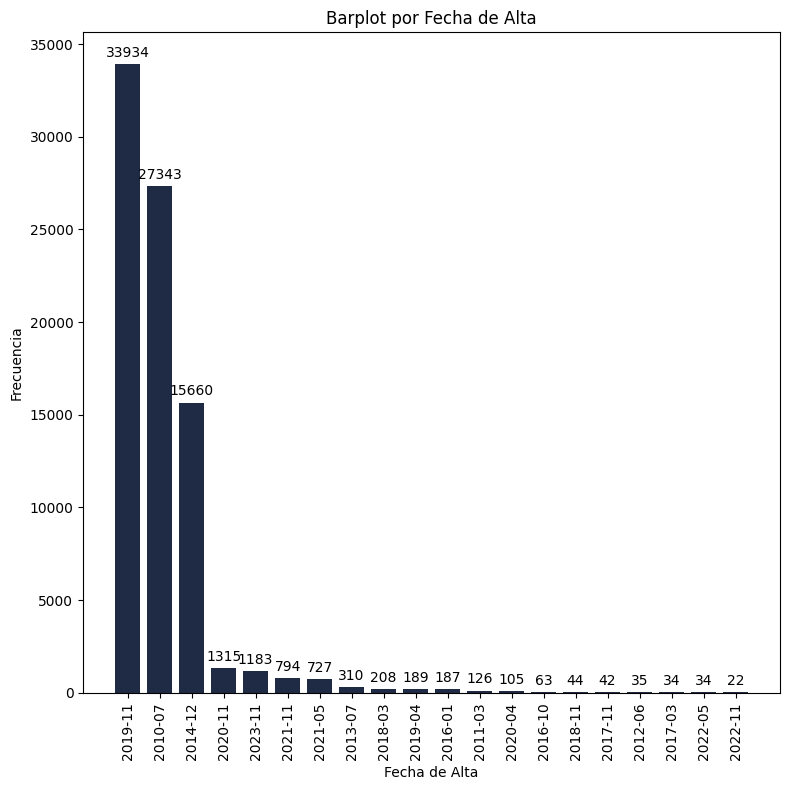

In [1161]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['fecha_alta'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Fecha de Alta') 
ax.set_xlabel('Fecha de Alta')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

In [1162]:
data['fecha_alta'].nunique()

20

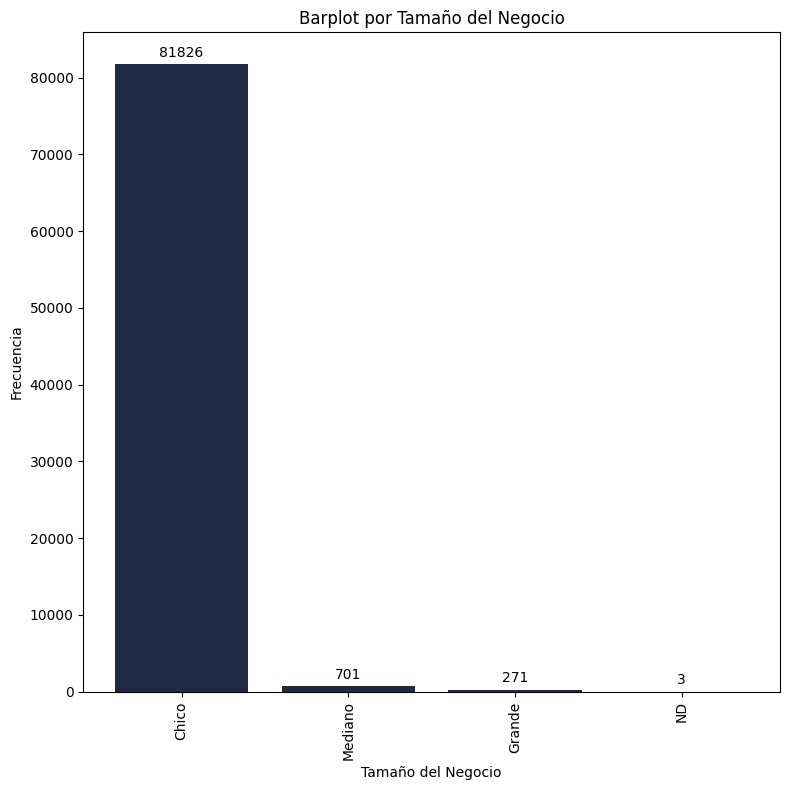

In [1163]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['Tam_negocio'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Barplot por Tamaño del Negocio') 
ax.set_xlabel('Tamaño del Negocio')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=90)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

In [1164]:
tabla = pd.crosstab(data['Tam_negocio'], data['per_ocu'])
tabla = pd.crosstab(
    data['Tam_negocio'],
    data['per_ocu'],
    margins=True,      # agrega totales
    margins_name="Total"
)

tabla

per_ocu,0 a 5 personas,6 a 10 personas,11 a 30 personas,31 a 50 personas,51 a 100 personas,101 a 250 personas,251 y más personas,Total
Tam_negocio,,,,,,,,
Chico,76412,3266,2148,0,0,0,0,81826
Grande,0,0,0,0,0,173,98,271
Mediano,0,0,0,423,278,0,0,701
ND,0,0,0,0,0,0,3,3
Total,76412,3266,2148,423,278,173,101,82801


In [1165]:
# Reemplaza ND por tamaño de negocio 'grande', ya que las 3 de ND tienen más de 251 personas en per_ocu
data.loc[(data['per_ocu'] == '251 y más personas') & (data['Tam_negocio'] == 'ND'), 'Tam_negocio'] = 'Grande'

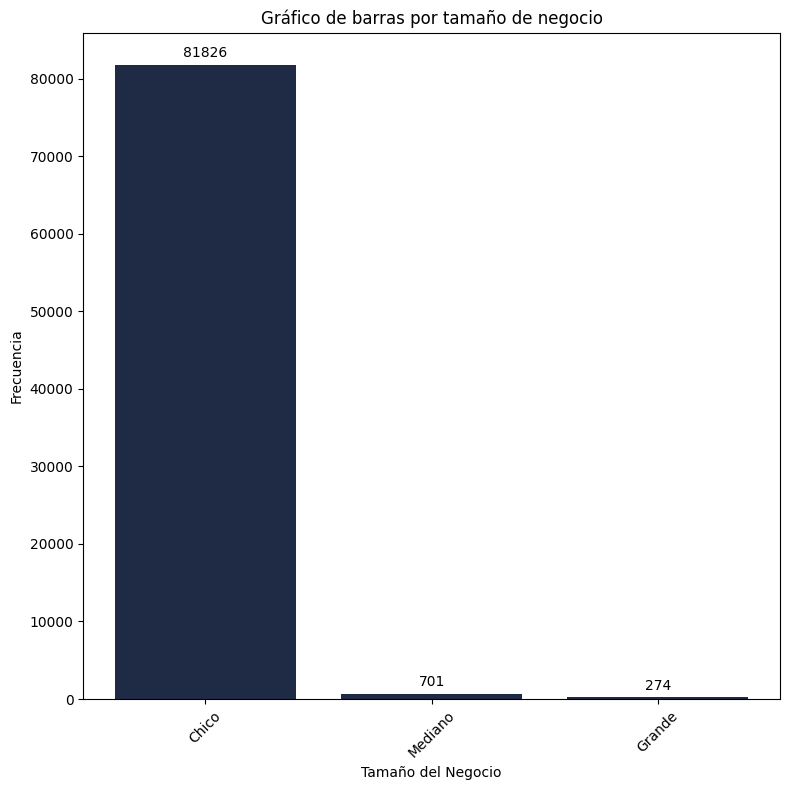

In [1166]:
fig, ax = plt.subplots(figsize=(8,8))

freq = data['Tam_negocio'].value_counts()
bars = ax.bar(x=freq.index, height=freq.to_list(), color='#1F2A44')

ax.set_title('Gráfico de barras por tamaño de negocio') 
ax.set_xlabel('Tamaño del Negocio')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=45)
ax.bar_label(bars, padding=3)


plt.tight_layout()
plt.show()

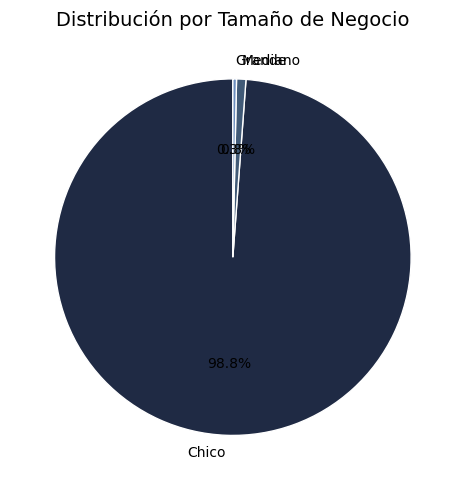

In [1167]:
# Contar frecuencias
freq = data['Tam_negocio'].value_counts()

# Paleta de colores
colores = ['#1F2A44', '#415A77', '#6C8EBF', '#8D99AE']

# Crear gráfico de pastel
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(
    freq, 
    labels=freq.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colores[:len(freq)], 
    wedgeprops={'edgecolor':'white'} 
)
ax.set_title('Distribución por Tamaño de Negocio', fontsize=14)

plt.tight_layout()
plt.show()

#### ¿En qué códigos postales hay mayor densidad comercial?

In [1168]:
# Agrupar por codigo postal y contar cantidad de establecimientos por código postal
mayor_densidad = data.groupby('cod_postal')['id'].count().reset_index(name='cantidad_establecimientos').sort_values(by='cantidad_establecimientos', ascending=False)
mayor_densidad.head(10)

,cod_postal,cantidad_establecimientos
94,90300,4202
259,90800,3042
159,90500,2935
245,90740,2793
0,90000,2268
95,90301,1805
88,90252,1784
297,90970,1775
220,90670,1661
144,90460,1627


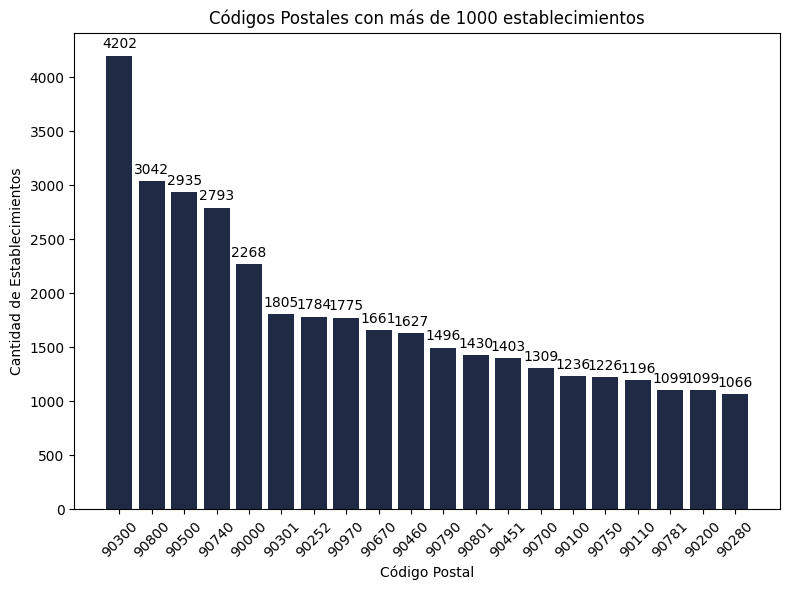

In [1169]:
# Visualización de los códigos postales con más de 1000 establecimientos
top_cp = mayor_densidad[mayor_densidad['cantidad_establecimientos'] > 1000]
fig, ax = plt.subplots(figsize=(8,6))

bars = ax.bar(
    x=top_cp['cod_postal'].astype(str), 
    height=top_cp['cantidad_establecimientos'],
    color='#1F2A44'
)

ax.set_title('Códigos Postales con más de 1000 establecimientos')
ax.set_xlabel('Código Postal')
ax.set_ylabel('Cantidad de Establecimientos')
ax.tick_params(axis='x', rotation=45)

ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

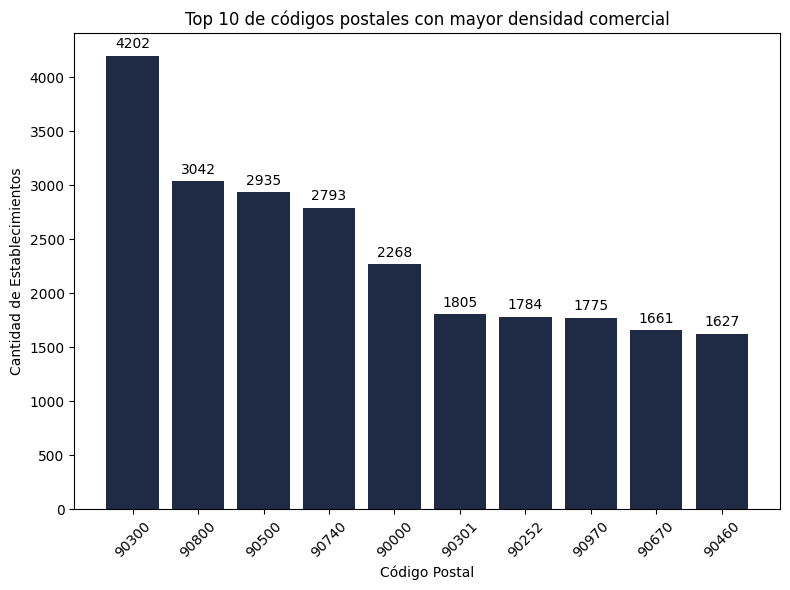

In [1170]:
# Mostrar top 10
# Visualización de los códigos postales top 10
top_cp = mayor_densidad.head(10)
fig, ax = plt.subplots(figsize=(8,6))

bars = ax.bar(
    x=top_cp['cod_postal'].astype(str), 
    height=top_cp['cantidad_establecimientos'],
    color='#1F2A44'   # Azul marino profundo
)

ax.set_title('Top 10 de códigos postales con mayor densidad comercial')
ax.set_xlabel('Código Postal')
ax.set_ylabel('Cantidad de Establecimientos')
ax.tick_params(axis='x', rotation=45)

ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

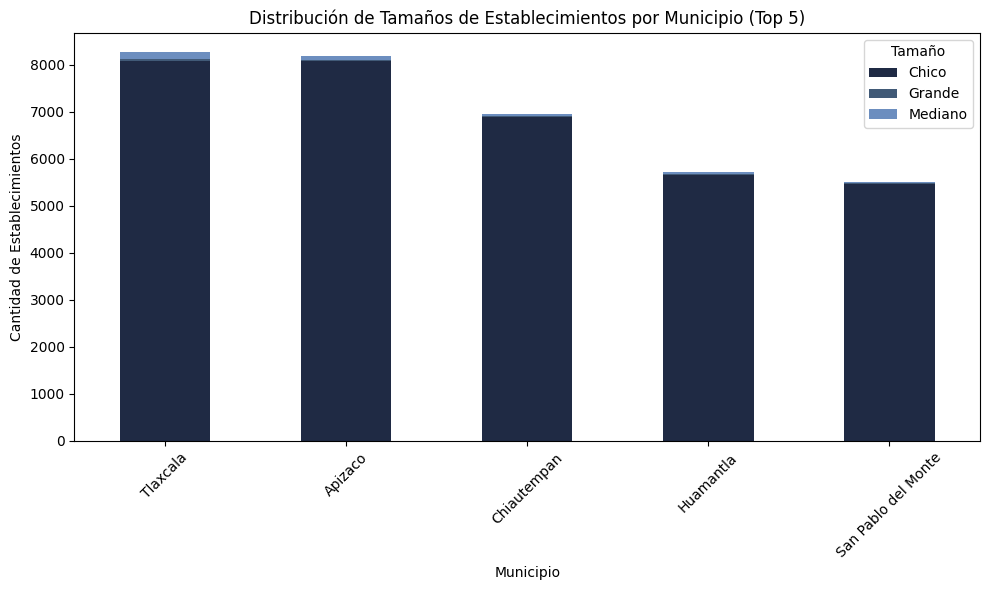

In [1171]:
# Pivot: cantidad de establecimientos por municipio y tamaño
pivot = data.groupby(['municipio', 'Tam_negocio']).size().unstack(fill_value=0)

# Seleccionamos los 10 municipios con más establecimientos totales
top10_municipios = pivot.sum(axis=1).sort_values(ascending=False).head(5).index
pivot_top10 = pivot.loc[top10_municipios]

paleta = ['#1F2A44', '#415A77', '#6C8EBF', '#8D99AE']

# Gráfico de barras apiladas con colores personalizados
pivot_top10.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10,6), 
    color=paleta
)

plt.title('Distribución de Tamaños de Establecimientos por Municipio (Top 5)')
plt.xlabel('Municipio')
plt.ylabel('Cantidad de Establecimientos')
plt.xticks(rotation=45)
plt.legend(title='Tamaño')
plt.tight_layout()
plt.show()

#### ¿Qué actividades económicas son preponderante en los códigos postales con mayor densidad comercial?

In [1172]:
top_cp = (
    data.groupby('cod_postal')['id']
    .count()
    .reset_index(name='cantidad_establecimientos')
    .sort_values(by='cantidad_establecimientos', ascending=False)
    .head(10)   
)

lista_top_cp = top_cp['cod_postal']

In [1173]:
# Filtramos para solo tener las actividades de los códigos postales con más establecimientos (top 10)
data_top_cp = data[data['cod_postal'].isin(lista_top_cp)]
data_top_cp

,lat,long,nombre_act,fuente,id,nom_estab,per_ocu,tipo_vial,nom_vial,tipo_asent,cod_postal,entidad,municipio,localidad,tipoUniEco,fecha_alta,Tam_negocio
287,19.338152,-98.175182,NaN,ServiciosEducativos,4204716,SECUNDARIA GENERAL MIGUEL N LIRA TURNO MATUTINO,51 a 100 personas,NaN,MIGUEL HIDALGO,NaN,90970,Tlaxcala,Contla de Juan Cuamatzi,Contla ...,Fijo,2010-07,Mediano
516,19.168704,-98.204857,Reparación autos,Otrosgubernamentales,9381327,SERVICIO AUTOMOTRIZ NAVA,0 a 5 personas,CALLE,MORELOS,LOCALIDAD,90970,Tlaxcala,Papalotla de Xicoht?©ncatl,Papalotla ...,Fijo,2021-11,Chico
517,19.166047,-98.204349,NaN,EsparcimientoCulturalyDeportivo,9377292,GIMNACIO GUERRERO GIM,0 a 5 personas,CALLE,CA?ëADA MORELOS,LOCALIDAD,90970,Tlaxcala,Papalotla de Xicoht?©ncatl,Papalotla ...,Fijo,2021-11,Chico
518,19.171148,-98.198317,NaN,Otrosgubernamentales,9373311,AUTOLAVADO NAVI,0 a 5 personas,AVENIDA,MAXIMO ROJAS,BARRIO,90970,Tlaxcala,Papalotla de Xicoht?©ncatl,Papalotla ...,Semifijo,2021-11,Chico
519,19.171175,-98.199165,NaN,SaludYAsistenciaSocial,9373310,DENTAL PASSEL MAYAHUEL,0 a 5 personas,AVENIDA,MAXIMO ROJAS,BARRIO,90970,Tlaxcala,Papalotla de Xicoht?©ncatl,Papalotla ...,Fijo,2021-11,Chico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82795,19.531715,-98.221578,NaN,ServiciosFinancieros,6838112,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,90301,Tlaxcala,Atlangatepec,Colonia Loma Bonita ...,Fijo,2018-03,Chico
82796,19.551195,-98.230190,NaN,ServiciosFinancieros,6838111,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,90301,Tlaxcala,Atlangatepec,Colonia Benito Ju?°rez (Tezoyo) ...,Fijo,2018-03,Chico
82797,19.600160,-98.226499,NaN,ServiciosFinancieros,6838901,CAJERO AUTOM?ÅTICO SANTANDER,0 a 5 personas,CALLE,NINGUNO,COLONIA,90252,Tlaxcala,Tlaxco,Tliltepec ...,Fijo,2018-03,Chico
82798,19.597650,-98.219987,NaN,ServiciosFinancieros,6888483,BANAMEX,0 a 5 personas,BOULEVARD,HERMANOS SERDAN,PARQUE INDUSTRIAL,90252,Tlaxcala,Tlaxco,San Antonio Huexotitla ...,Fijo,2019-04,Chico


In [1174]:
# Contar las actividades preponderantes en los códigos postales con más establecimientos
actividades_preponderantes = (
    data_top_cp['nombre_act']
    .value_counts()
    .reset_index()
)

In [1175]:
# Contar la cantidad de cada actividad por código postal
actividades_por_cp = (
    data_top_cp
    .groupby(['cod_postal', 'nombre_act'])
    .size()
    .reset_index(name='cantidad')
    .sort_values(['cod_postal', 'cantidad'], ascending=[True, False])
)

In [1176]:
# Muestra la actividad preponderante por código postal
idx = actividades_por_cp.groupby('cod_postal')['cantidad'].idxmax()
actividad_dominante = actividades_por_cp.loc[idx]

actividad_dominante.sort_values('cantidad', ascending=False)

,cod_postal,nombre_act,cantidad
51,90301,Abarrotes,370
119,90740,Abarrotes,346
68,90460,Abarrotes,281
85,90500,Abarrotes,280
17,90252,Abarrotes,236
48,90300,Ropa,236
150,90800,Ropa,224
102,90670,Abarrotes,222
153,90970,Abarrotes,172
14,90000,Ropa,104


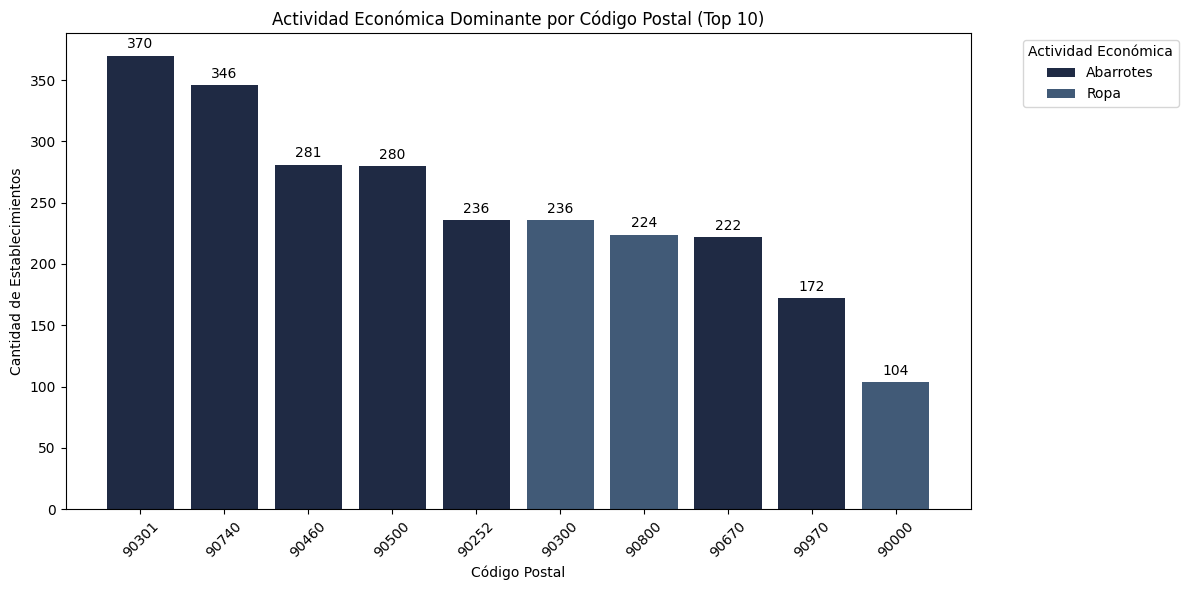

In [1177]:
# Seleccionamos los 10 códigos postales con más establecimientos
top10 = actividad_dominante.sort_values('cantidad', ascending=False).head(10)


# Graficamos usando la columna corta para la leyenda
fig, ax = plt.subplots(figsize=(12,6))

actividades = top10['nombre_act'].unique()
paleta = ['#1F2A44', '#415A77', '#6C8EBF', '#8D99AE']

color_dict = {
    act: paleta[i % len(paleta)]
    for i, act in enumerate(actividades)
}
bars = ax.bar(
    x=top10['cod_postal'].astype(str),
    height=top10['cantidad'],
    color=[color_dict[act] for act in top10['nombre_act']]
)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_dict[act], label=act) for act in actividades]
ax.legend(handles=legend_elements, title="Actividad Económica", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_title('Actividad Económica Dominante por Código Postal (Top 10)')
ax.set_xlabel('Código Postal')
ax.set_ylabel('Cantidad de Establecimientos')
ax.tick_params(axis='x', rotation=45)
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

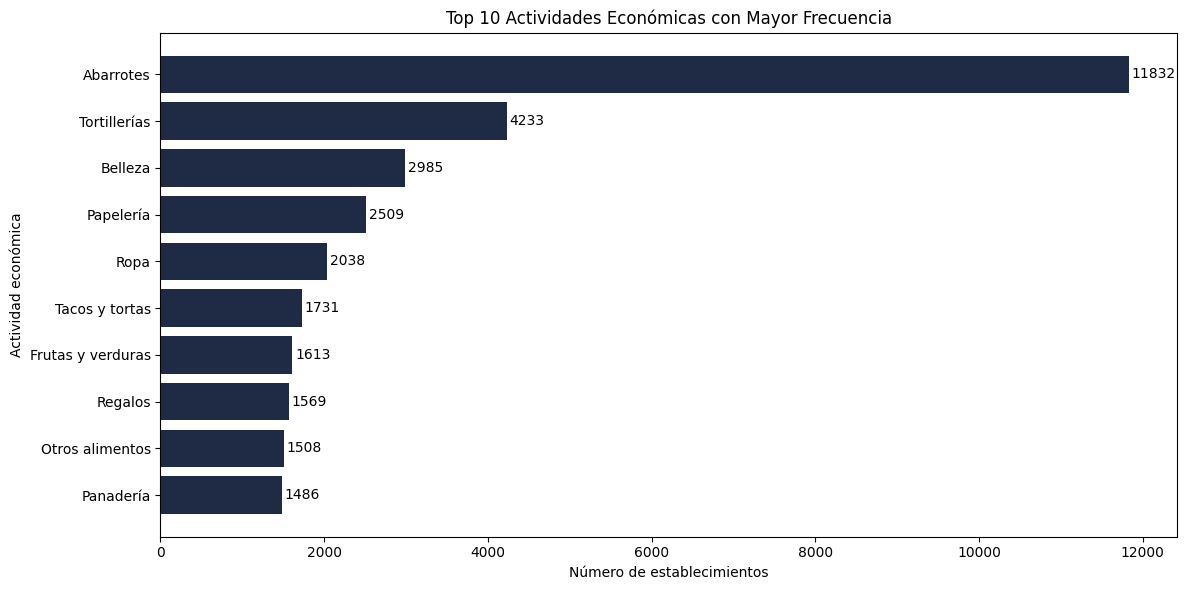

In [1178]:
# Actividades económicas más frecuentes en los códigos postales con más establecimientos
# Contar frecuencias

freq = data['nombre_act'].value_counts()

top10 = freq.head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top10.index[::-1], 
    top10.values[::-1], 
    color='#1F2A44'
)

plt.title('Top 10 Actividades Económicas con Mayor Frecuencia')
plt.xlabel('Número de establecimientos')
plt.ylabel('Actividad económica')


plt.bar_label(bars, padding=2)

plt.tight_layout()
plt.show()

#### ¿Existe alguna diferencia significativa entre el tamaño de los negocios? Da evidencia de tu respuesta.

Se realizó una prueba de chi-cuadrada para evaluar la relación entre el municipio y el tamaño de los negocios.

##### Hipótesis

$H_{\theta}$: No existe una relación estadísticamente significativa entre el municipio y el tamaño del negocio. Es decir, el tamaño del negocio es independiente del municipio.

$H_{1}$: Existe una relación estadísticamente significativa entre el municipio y el tamaño del negocio.
Es decir, la distribución del tamaño de los negocios depende del municipio.

Se trabajó con un nivel de significancia de α = 0.05.

In [1179]:
from scipy.stats import chi2_contingency

pd.crosstab(data["municipio"], data["Tam_negocio"])
tabla = pd.crosstab(data["municipio"], data["Tam_negocio"])
chi2, p, dof, expected = chi2_contingency(tabla)

print("p-value:", p)

p-value: 2.9796092919206498e-33


Dado que el valor p es menor a 0.05, se rechaza la hipótesis nula.

Conclusión

Se realizó una prueba de chi-cuadrada para evaluar la relación entre el municipio y el tamaño de los negocios, con un nivel de significancia de α = 0.05. El resultado arrojó un valor p = 2.98e-33, el cual es menor que el nivel de significancia establecido. Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una relación estadísticamente significativa entre el municipio y el tamaño del negocio. Esto indica que la distribución de los tamaños de negocio varía entre los distintos municipios de Tlaxcala.

In [1180]:
# Tamaño vs Actividad económica
tabla = pd.crosstab(data['nombre_act'], data['Tam_negocio'])
chi2, p, dof, expected = chi2_contingency(tabla)

print(p)

3.735727016816578e-123


##### Hipótesis

$H_{\theta}$: No existe una relación estadísticamente significativa entre la actividad económica y el tamaño del negocio.
Es decir, la distribución del tamaño de los negocios es independiente de la actividad económica

$H_{1}$: Existe una relación estadísticamente significativa entre la actividad económica y el tamaño del negocio.
Es decir, la distribución del tamaño de los negocios depende de la actividad económica.

Se trabajó con un nivel de significancia de α = 0.05.

Conclusión

Existe una relación estadísticamente significativa entre la actividad económica y el tamaño del negocio.
Esto implica que la distribución del tamaño de los negocios depende del tipo de actividad económica, evidenciando estructuras empresariales distintas entre sectores.

#### Si organizaras los datos por código postal ¿De qué manera lo harías y con qué otras bases complementarías el análisis?

Para organizar los datos por código postal, se agruparían los establecimientos según esta variable con el objetivo de analizar la concentración de negocios, su tamaño y su distribución geográfica en cada zona. Esto permitiría identificar áreas con mayor densidad comercial, así como zonas con predominio de pequeñas, medianas o grandes empresas.

Posteriormente, el análisis podría complementarse con bases de datos externas como los Censos Económicos y los datos sociodemográficos del INEGI, que proporcionan información sobre población, ingresos y características del entorno económico. También sería útil integrar información geoespacial para analizar la accesibilidad, infraestructura y proximidad a zonas comerciales o de alto flujo de personas.

De esta manera, el análisis por código postal permitiría entender mejor la estructura económica local y detectar oportunidades para la expansión comercial o el desarrollo económico en determinadas zonas

In [1181]:
pd.crosstab(data["cod_postal"], data["Tam_negocio"], normalize="index")

Tam_negocio,Chico,Grande,Mediano
cod_postal,,,
90000,0.971781,0.010582,0.017637
90001,0.666667,0.000000,0.333333
90006,1.000000,0.000000,0.000000
90008,1.000000,0.000000,0.000000
90010,0.976190,0.000000,0.023810
...,...,...,...
90963,1.000000,0.000000,0.000000
90970,0.987606,0.000563,0.011831
90980,1.000000,0.000000,0.000000


#### ¿Qué tipo de modelo propondrías para predecir la segmentación geoespacial de los negocios y por qué?

In [1182]:
# Densidad (número de negocios por CP)
cp_agg = data.groupby("cod_postal").agg({
    "id": "count",
    "nombre_act": "nunique",
    "lat": "mean",
    "long": "mean"
}).reset_index()

cp_agg.columns = ["cod_postal", "num_negocios", "diversidad", "lat_mean", "long_mean"]

cp_agg.head()

,cod_postal,num_negocios,diversidad,lat_mean,long_mean
0,90000,2268,17,19.318406,-98.237586
1,90001,3,0,19.324310,-98.222931
2,90006,4,0,19.298814,-98.248233
3,90008,1,0,19.317415,-98.242634
4,90010,210,13,19.327068,-98.219532


In [1183]:
from sklearn.preprocessing import StandardScaler

features = ["num_negocios", "diversidad", "lat_mean", "long_mean"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cp_agg[features])

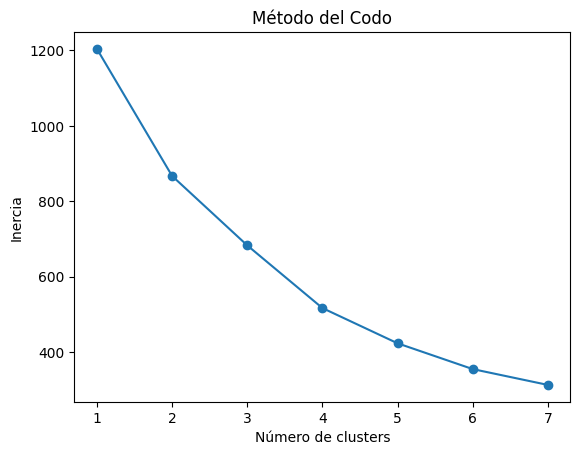

In [1184]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,8), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [1185]:
kmeans = KMeans(n_clusters=4, random_state=42)
cp_agg["cluster"] = kmeans.fit_predict(X_scaled)

cp_agg.head()

,cod_postal,num_negocios,diversidad,lat_mean,long_mean,cluster
0,90000,2268,17,19.318406,-98.237586,2
1,90001,3,0,19.324310,-98.222931,1
2,90006,4,0,19.298814,-98.248233,1
3,90008,1,0,19.317415,-98.242634,1
4,90010,210,13,19.327068,-98.219532,3


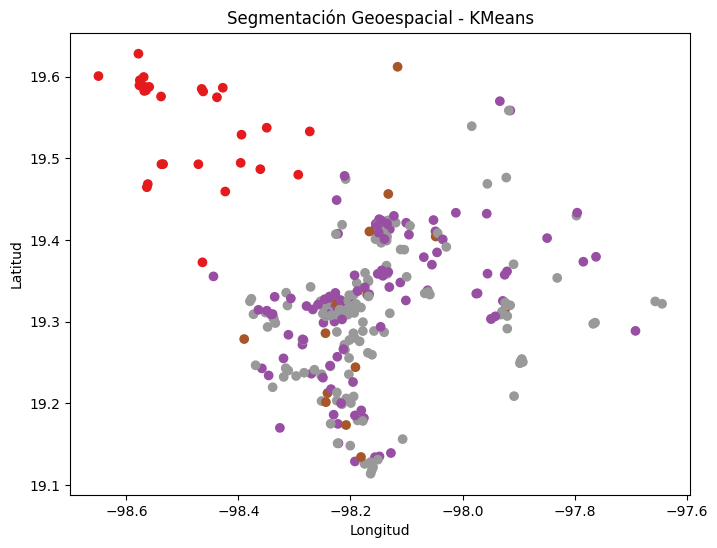

In [1186]:
plt.figure(figsize=(8,6))
plt.scatter(cp_agg["long_mean"],
            cp_agg["lat_mean"],
            c=cp_agg["cluster"],
            cmap="Set1")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Segmentación Geoespacial - KMeans")
plt.show()

In [1187]:
cp_agg.groupby("cluster")[["num_negocios","diversidad"]].mean()

,num_negocios,diversidad
cluster,,
0,231.241379,9.275862
1,7.892857,1.633929
2,1952.235294,17.000000
3,293.867133,15.006993


#### ¿Qué gráficos serían más efectivos para comunicar los resultados y por qué?

In [1188]:
pip install folium


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1189]:
import folium

In [1190]:
mapa = folium.Map(
    location=[cp_agg['lat_mean'].mean(), cp_agg['long_mean'].mean()],
    zoom_start=10
)

for _, row in cp_agg.iterrows():
    folium.CircleMarker(
        location=[row['lat_mean'], row['long_mean']],
        radius=row['num_negocios'] / 10,  # escala visual
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=f"CP: {row['cod_postal']}<br>Negocios: {row['num_negocios']}"
    ).add_to(mapa)

mapa

In [1191]:
colors = ['red', 'blue', 'green', 'purple']

mapa = folium.Map(
    location=[cp_agg['lat_mean'].mean(), cp_agg['long_mean'].mean()],
    zoom_start=11,
    tiles="cartodbpositron"
)

max_negocios = cp_agg['num_negocios'].max()

for _, row in cp_agg.iterrows():
    radio = 200 * np.sqrt(row['num_negocios'] / max_negocios)

    folium.Circle(
        location=[row['lat_mean'], row['long_mean']],
        radius=radio,
        color=colors[int(row['cluster'])],
        fill=True,
        fill_color=colors[int(row['cluster'])],
        fill_opacity=0.45,
        tooltip=f"CP {int(row['cod_postal'])} | Negocios: {row['num_negocios']}",
        popup=f"""
        <b>Código Postal:</b> {int(row['cod_postal'])}<br>
        <b>Negocios:</b> {row['num_negocios']}<br>
        <b>Cluster:</b> {int(row['cluster'])}
        """
    ).add_to(mapa)

mapa

In [1192]:
mapa.save("mapa_densidad_comercial.html")